# Avance 2 - Feature Engineering en datos de vibración

El objetivo de esta libreta es transformar las mediciones crudas de vibración en un conjunto de características listo para modelado dentro de la metodología CRISP-ML. Se aplican técnicas de limpieza, construcción de variables, codificación, escalamiento, transformaciones y reducción de dimensionalidad sobre el mismo dataset de tres bombas usado en avances anteriores.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, f_oneway, skew
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, PowerTransformer, StandardScaler

# Configuracion general
RANDOM_STATE = 42
VARIANCE_THRESHOLD = 0.01
PCA_VARIANCE = 0.95
FA_COMPONENTS = 2

PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "vibracion.csv"
OUTPUT_PATH = PROJECT_DIR / "dataset_procesado_completo.csv"

warnings.filterwarnings("ignore")
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

print("Ambiente listo")
print(f"Directorio de trabajo: {PROJECT_DIR}")
print(f"Archivo de datos: {DATA_PATH.name} | existe: {DATA_PATH.exists()}")


Ambiente listo
Directorio de trabajo: /Users/leonardo/Documents/ProyectoIntegrador/ProyectoIntegradorMNA/Avance2.58/FE - Feature Engineering
Archivo de datos: vibracion.csv | existe: True


## 1. Carga y validación de datos

Se utiliza una ruta relativa porque `vibracion.csv` se entrega en la misma carpeta que la libreta. Esto permite que el notebook se ejecute en otra computadora sin depender de rutas locales de un integrante del equipo.


In [2]:
required_columns = [
    "timesTamp",
    "parameterName",
    "sensorId",
    "RMSVelocityH",
    "RMSVelocityV",
    "RMSVelocityA",
]

if not DATA_PATH.exists():
    raise FileNotFoundError(f"No se encontro el archivo: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
missing_columns = sorted(set(required_columns) - set(df.columns))
if missing_columns:
    raise ValueError(f"Faltan columnas requeridas: {missing_columns}")

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print("Valores nulos por columna:")
print(df[required_columns].isna().sum())

df.head()


Filas: 52,560
Columnas: 6
Valores nulos por columna:
timesTamp        0
parameterName    0
sensorId         0
RMSVelocityH     0
RMSVelocityV     0
RMSVelocityA     0
dtype: int64


,timesTamp,parameterName,sensorId,RMSVelocityH,RMSVelocityV,RMSVelocityA
0,2025-01-01 00:00:00,Pump_1,189310001,0.2970,0.2550,0.3530
1,2025-01-01 00:30:00,Pump_1,189310001,0.2990,0.2430,0.3590
2,2025-01-01 01:00:00,Pump_1,189310001,0.2970,0.2480,0.3500
3,2025-01-01 01:30:00,Pump_1,189310001,0.3070,0.2470,0.3440
4,2025-01-01 02:00:00,Pump_1,189310001,0.3020,0.2560,0.3570


## 2. Inspección inicial del dataset

Antes de transformar variables conviene revisar tipos, rangos y valores faltantes. Esta inspección orienta qué columnas requieren limpieza, cuáles son numéricas y si existen duplicados que puedan sesgar estadísticas o modelos posteriores.


In [3]:
df.head()

print("\nInformacion general:")
df.info()

print("\nDescripcion estadistica de variables RMS:")
df[["RMSVelocityH", "RMSVelocityV", "RMSVelocityA"]].describe().round(4)

print("\nRegistros por bomba/sensor:")
print(df.groupby(["parameterName", "sensorId"]).size())

print("\nValores nulos:")
print(df.isnull().sum())



Informacion general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52560 entries, 0 to 52559
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timesTamp      52560 non-null  object 
 1   parameterName  52560 non-null  object 
 2   sensorId       52560 non-null  int64  
 3   RMSVelocityH   52560 non-null  float64
 4   RMSVelocityV   52560 non-null  float64
 5   RMSVelocityA   52560 non-null  float64
dtypes: float64(3), int64(1), object(2)
memory usage: 2.4+ MB

Descripcion estadistica de variables RMS:

Registros por bomba/sensor:
parameterName  sensorId 
Pump_1         189310001    17520
Pump_2         189310002    17520
Pump_3         189310003    17520
dtype: int64

Valores nulos:
timesTamp        0
parameterName    0
sensorId         0
RMSVelocityH     0
RMSVelocityV     0
RMSVelocityA     0
dtype: int64


## 3. Limpieza básica

Se eliminan registros duplicados y se imputan valores faltantes numéricos con la media de cada columna. Esta decisión es simple y reproducible; si en etapas posteriores se detecta sesgo por imputación, conviene reemplazarla por estrategias por sensor o por ventana temporal.


In [4]:
rows_before = df.shape[0]
df = df.drop_duplicates()

numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

print(f"Duplicados eliminados: {rows_before - df.shape[0]:,}")
print(f"Filas despues de limpieza: {df.shape[0]:,}")
print(f"Valores nulos restantes: {df.isnull().sum().sum()}")


Duplicados eliminados: 0
Filas despues de limpieza: 52,560
Valores nulos restantes: 0


## 4. Generación de características

**Pregunta: ¿Qué variables derivadas aportan información útil para modelar vibración?**

A partir de los tres ejes RMS se construye una magnitud combinada (`vibracion_rms`) que resume la intensidad general de la señal. Esta variable agrega una representación compacta del comportamiento vibratorio y facilita comparaciones entre sensores sin depender de un solo eje.


In [5]:
rms_cols = ["RMSVelocityH", "RMSVelocityV", "RMSVelocityA"]

df["vibracion_rms"] = np.sqrt(
    (df[rms_cols[0]] ** 2 + df[rms_cols[1]] ** 2 + df[rms_cols[2]] ** 2) / 3
)

print("Nueva caracteristica creada: vibracion_rms")
print(df[["parameterName", "sensorId"] + rms_cols + ["vibracion_rms"]].head())


Nueva caracteristica creada: vibracion_rms
  parameterName   sensorId  RMSVelocityH  RMSVelocityV  RMSVelocityA  \
0        Pump_1  189310001        0.2970        0.2550        0.3530   
1        Pump_1  189310001        0.2990        0.2430        0.3590   
2        Pump_1  189310001        0.2970        0.2480        0.3500   
3        Pump_1  189310001        0.3070        0.2470        0.3440   
4        Pump_1  189310001        0.3020        0.2560        0.3570   

   vibracion_rms  
0         0.3043  
1         0.3040  
2         0.3012  
3         0.3020  
4         0.3078  


## 5. Discretización y codificación

**Pregunta: ¿Cómo preparar variables categóricas para algoritmos de ML?**

La variable `vibracion_rms` se discretiza en tres niveles (`Baja`, `Media`, `Alta`) para facilitar análisis por grupos y pruebas estadísticas. Luego se codifica de dos formas:

- **Label encoding:** asigna un entero ordenado a cada categoría; útil para métodos que aceptan variables ordinales.
- **One-hot encoding:** crea columnas binarias por categoría y evita imponer un orden artificial entre niveles.

Se conservan ambas codificaciones para comparar su utilidad en modelos posteriores.


In [6]:
df["nivel_vibracion"] = pd.cut(
    df["vibracion_rms"],
    bins=3,
    labels=["Baja", "Media", "Alta"],
)

le = LabelEncoder()
df["nivel_vibracion_cod"] = le.fit_transform(df["nivel_vibracion"])

categorical_cols = df.select_dtypes(include="object").columns.tolist()
if categorical_cols:
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Distribucion de nivel_vibracion:")
print(df["nivel_vibracion"].value_counts())

print(f"\nColumnas categoricas codificadas: {categorical_cols}")
print(f"Columnas totales despues de codificacion: {df.shape[1]}")
df.head()


Distribucion de nivel_vibracion:
nivel_vibracion
Media    21914
Baja     18093
Alta     12553
Name: count, dtype: int64

Columnas categoricas codificadas: ['timesTamp', 'parameterName']
Columnas totales despues de codificacion: 17528


,sensorId,RMSVelocityH,RMSVelocityV,RMSVelocityA,vibracion_rms,nivel_vibracion,nivel_vibracion_cod,timesTamp_2025-01-01 00:30:00,timesTamp_2025-01-01 01:00:00,timesTamp_2025-01-01 01:30:00,timesTamp_2025-01-01 02:00:00,timesTamp_2025-01-01 02:30:00,timesTamp_2025-01-01 03:00:00,timesTamp_2025-01-01 03:30:00,timesTamp_2025-01-01 04:00:00,timesTamp_2025-01-01 04:30:00,timesTamp_2025-01-01 05:00:00,timesTamp_2025-01-01 05:30:00,timesTamp_2025-01-01 06:00:00,timesTamp_2025-01-01 06:30:00,timesTamp_2025-01-01 07:00:00,timesTamp_2025-01-01 07:30:00,timesTamp_2025-01-01 08:00:00,timesTamp_2025-01-01 08:30:00,timesTamp_2025-01-01 09:00:00,timesTamp_2025-01-01 09:30:00,timesTamp_2025-01-01 10:00:00,timesTamp_2025-01-01 10:30:00,timesTamp_2025-01-01 11:00:00,timesTamp_2025-01-01 11:30:00,timesTamp_2025-01-01 12:00:00,timesTamp_2025-01-01 12:30:00,timesTamp_2025-01-01 13:00:00,timesTamp_2025-01-01 13:30:00,timesTamp_2025-01-01 14:00:00,timesTamp_2025-01-01 14:30:00,timesTamp_2025-01-01 15:00:00,timesTamp_2025-01-01 15:30:00,timesTamp_2025-01-01 16:00:00,timesTamp_2025-01-01 16:30:00,timesTamp_2025-01-01 17:00:00,timesTamp_2025-01-01 17:30:00,timesTamp_2025-01-01 18:00:00,timesTamp_2025-01-01 18:30:00,timesTamp_2025-01-01 19:00:00,timesTamp_2025-01-01 19:30:00,timesTamp_2025-01-01 20:00:00,timesTamp_2025-01-01 20:30:00,timesTamp_2025-01-01 21:00:00,timesTamp_2025-01-01 21:30:00,...,timesTamp_2025-12-31 00:00:00,timesTamp_2025-12-31 00:30:00,timesTamp_2025-12-31 01:00:00,timesTamp_2025-12-31 01:30:00,timesTamp_2025-12-31 02:00:00,timesTamp_2025-12-31 02:30:00,timesTamp_2025-12-31 03:00:00,timesTamp_2025-12-31 03:30:00,timesTamp_2025-12-31 04:00:00,timesTamp_2025-12-31 04:30:00,timesTamp_2025-12-31 05:00:00,timesTamp_2025-12-31 05:30:00,timesTamp_2025-12-31 06:00:00,timesTamp_2025-12-31 06:30:00,timesTamp_2025-12-31 07:00:00,timesTamp_2025-12-31 07:30:00,timesTamp_2025-12-31 08:00:00,timesTamp_2025-12-31 08:30:00,timesTamp_2025-12-31 09:00:00,timesTamp_2025-12-31 09:30:00,timesTamp_2025-12-31 10:00:00,timesTamp_2025-12-31 10:30:00,timesTamp_2025-12-31 11:00:00,timesTamp_2025-12-31 11:30:00,timesTamp_2025-12-31 12:00:00,timesTamp_2025-12-31 12:30:00,timesTamp_2025-12-31 13:00:00,timesTamp_2025-12-31 13:30:00,timesTamp_2025-12-31 14:00:00,timesTamp_2025-12-31 14:30:00,timesTamp_2025-12-31 15:00:00,timesTamp_2025-12-31 15:30:00,timesTamp_2025-12-31 16:00:00,timesTamp_2025-12-31 16:30:00,timesTamp_2025-12-31 17:00:00,timesTamp_2025-12-31 17:30:00,timesTamp_2025-12-31 18:00:00,timesTamp_2025-12-31 18:30:00,timesTamp_2025-12-31 19:00:00,timesTamp_2025-12-31 19:30:00,timesTamp_2025-12-31 20:00:00,timesTamp_2025-12-31 20:30:00,timesTamp_2025-12-31 21:00:00,timesTamp_2025-12-31 21:30:00,timesTamp_2025-12-31 22:00:00,timesTamp_2025-12-31 22:30:00,timesTamp_2025-12-31 23:00:00,timesTamp_2025-12-31 23:30:00,parameterName_Pump_2,parameterName_Pump_3
0,189310001,0.2970,0.2550,0.3530,0.3043,Baja,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,189310001,0.2990,0.2430,0.3590,0.3040,Baja,1,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fals

## 6. Escalamiento y transformaciones

**Pregunta: ¿Por qué normalizar y transformar antes del modelado?**

Los algoritmos sensibles a la escala (PCA, regresiones, redes neuronales) requieren variables comparables. Se aplican estandarización (media 0, desviación 1) y normalización Min-Max (rango [0, 1]) como referencias. Además, transformaciones logarítmica y Yeo-Johnson ayudan a reducir asimetría y el impacto de valores extremos en la distribución de las señales.


In [7]:
numeric_df = df.select_dtypes(include=np.number)

scaler_std = StandardScaler()
X_std = pd.DataFrame(
    scaler_std.fit_transform(numeric_df),
    columns=numeric_df.columns,
)

scaler_mm = MinMaxScaler()
X_mm = pd.DataFrame(
    scaler_mm.fit_transform(numeric_df),
    columns=numeric_df.columns,
)

df["vibracion_log"] = np.log1p(df["vibracion_rms"])

pt = PowerTransformer(method="yeo-johnson")
X_power = pd.DataFrame(
    pt.fit_transform(numeric_df),
    columns=numeric_df.columns,
)

print("Datos estandarizados (muestra):")
print(X_std.head())

print("\nDatos normalizados Min-Max (muestra):")
print(X_mm.head())

print("\nDatos transformados Yeo-Johnson (muestra):")
print(X_power.head())


Datos estandarizados (muestra):
   sensorId  RMSVelocityH  RMSVelocityV  RMSVelocityA  vibracion_rms  \
0   -1.2247       -1.8489       -1.5393       -1.6130        -1.8427   
1   -1.2247       -1.8448       -1.5549       -1.6036        -1.8432   
2   -1.2247       -1.8489       -1.5484       -1.6177        -1.8481   
3   -1.2247       -1.8285       -1.5497       -1.6271        -1.8468   
4   -1.2247       -1.8387       -1.5380       -1.6068        -1.8368   

   nivel_vibracion_cod  
0              -0.2255  
1              -0.2255  
2              -0.2255  
3              -0.2255  
4              -0.2255  

Datos normalizados Min-Max (muestra):
   sensorId  RMSVelocityH  RMSVelocityV  RMSVelocityA  vibracion_rms  \
0    0.0000        0.0632        0.0552        0.0836         0.0027   
1    0.0000        0.0640        0.0519        0.0856         0.0025   
2    0.0000        0.0632        0.0532        0.0825         0.0014   
3    0.0000        0.0672        0.0530        0.0805     

## 7. Análisis exploratorio de distribuciones

Se revisa la asimetría de las variables numéricas y se visualizan histogramas, boxplots y la matriz de correlación. Estas gráficas permiten detectar outliers, relaciones lineales fuertes entre ejes RMS y decidir si conviene reducir redundancia antes del modelado.


Asimetria de variables numericas:
sensorId: 0.0000
RMSVelocityH: -0.1228
RMSVelocityV: 0.1733
RMSVelocityA: 0.0536
vibracion_rms: 0.0946
nivel_vibracion_cod: -0.3265


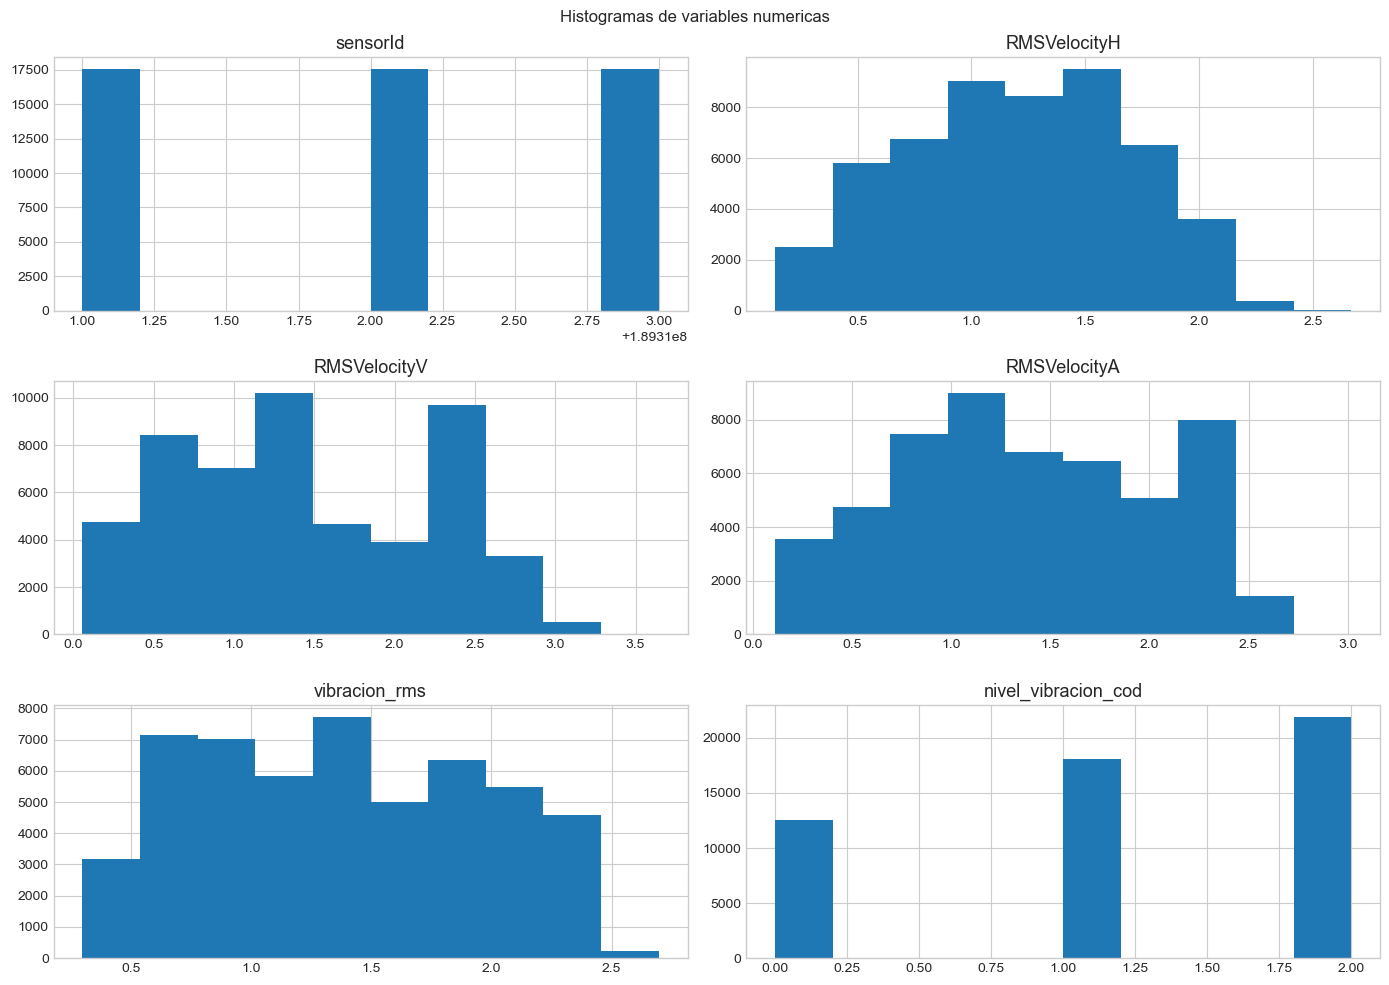

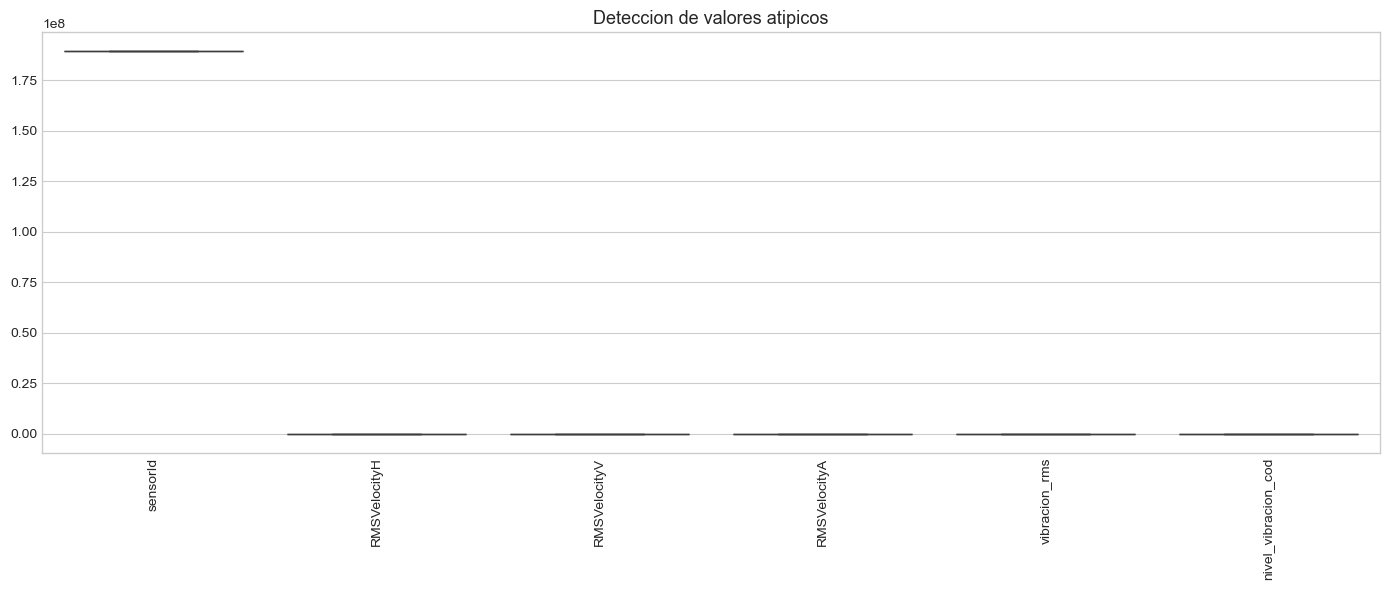

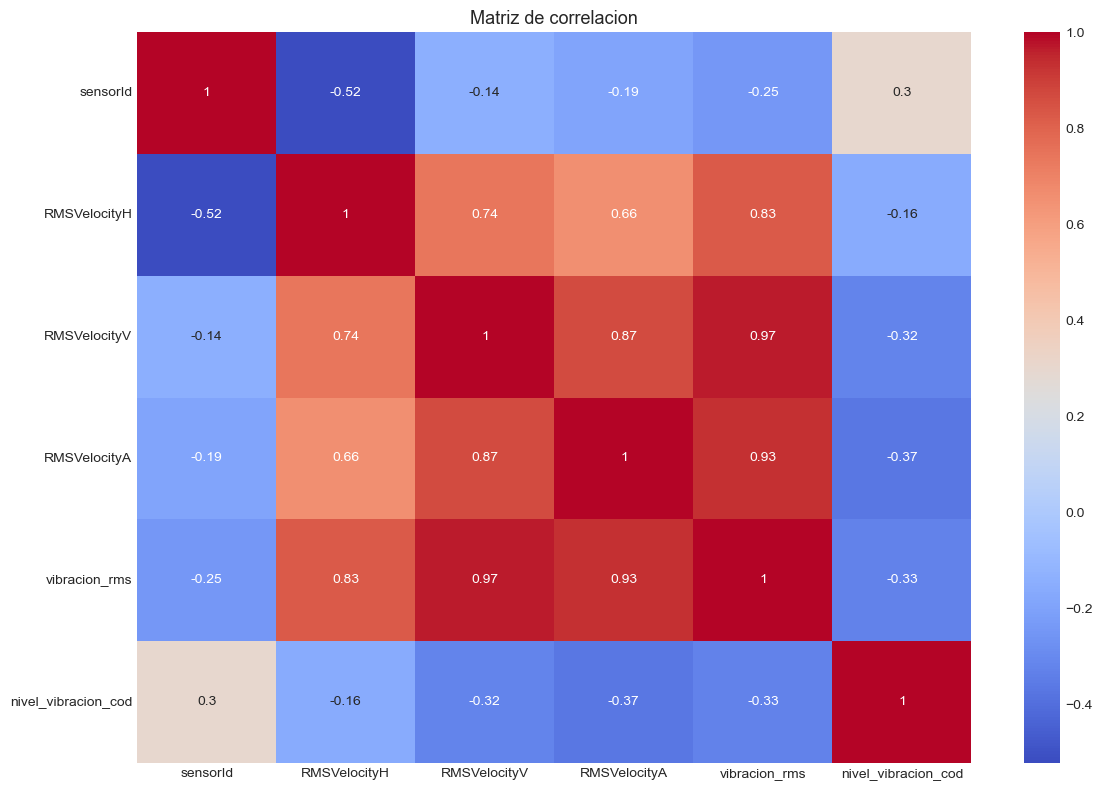

In [8]:
print("Asimetria de variables numericas:")
for col in numeric_df.columns:
    print(f"{col}: {skew(numeric_df[col]):.4f}")

numeric_df.hist(figsize=(14, 10))
plt.suptitle("Histogramas de variables numericas")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.boxplot(data=numeric_df)
plt.xticks(rotation=90)
plt.title("Deteccion de valores atipicos")
plt.tight_layout()
plt.show()

corr_matrix = numeric_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True)
plt.title("Matriz de correlacion")
plt.tight_layout()
plt.show()


## 8. Selección y reducción de dimensionalidad

**Pregunta: ¿Cómo reducir redundancia sin perder señal relevante?**

Se combinan métodos filter y de extracción:

- **Umbral de varianza:** descarta columnas casi constantes.
- **Chi-cuadrado y ANOVA:** evalúan relación entre `nivel_vibracion` y otras variables.
- **PCA:** resume la varianza en componentes ortogonales.
- **Análisis factorial:** explora factores latentes como complemento interpretativo.

Estas técnicas no reemplazan el criterio de dominio; sirven para priorizar variables antes de entrenar modelos en avances posteriores.


Caracteristicas seleccionadas por umbral de varianza:
['sensorId', 'RMSVelocityH', 'RMSVelocityV', 'RMSVelocityA', 'vibracion_rms', 'nivel_vibracion_cod']

Chi-cuadrado (nivel_vibracion vs codificacion numerica):
Chi2: 105120.0000 | p-value: 0.0000

ANOVA (vibracion_rms por nivel):
F-statistic: 197787.0547 | p-value: 0.0000

PCA
Numero de componentes: 3
Varianza explicada por componente:
[0.6282 0.1803 0.1429]


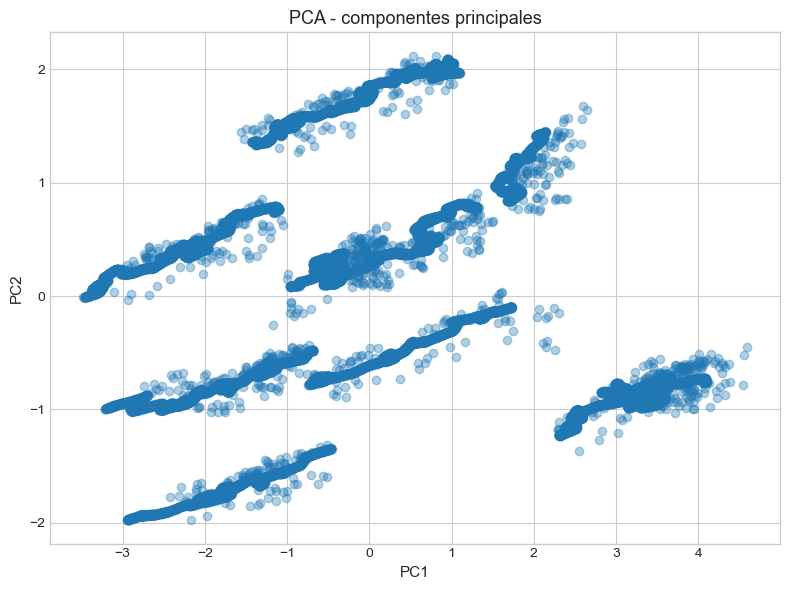


Analisis factorial (muestra):
[[-1.8607109   0.51496547]
 [-1.8609336   0.50696941]
 [-1.86578938  0.50693773]
 [-1.86333632  0.47261328]
 [-1.85444829  0.50576292]]


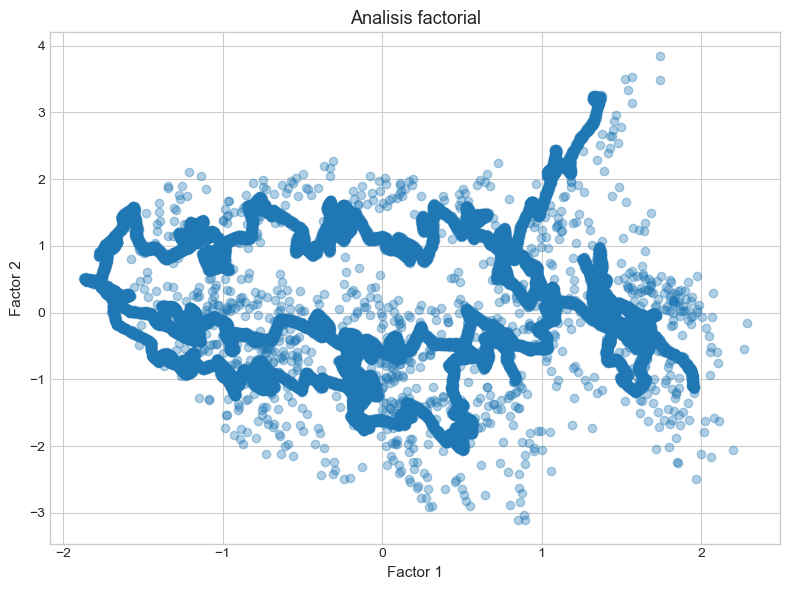

In [9]:
selector = VarianceThreshold(threshold=VARIANCE_THRESHOLD)
selector.fit(numeric_df)
selected_features = numeric_df.columns[selector.get_support()]

print("Caracteristicas seleccionadas por umbral de varianza:")
print(list(selected_features))

if "nivel_vibracion" in df.columns:
    tabla = pd.crosstab(df["nivel_vibracion"], df["nivel_vibracion_cod"])
    chi2, p_chi2, dof, expected = chi2_contingency(tabla)
    print("\nChi-cuadrado (nivel_vibracion vs codificacion numerica):")
    print(f"Chi2: {chi2:.4f} | p-value: {p_chi2:.4f}")

    grupos = [
        df.loc[df["nivel_vibracion"] == categoria, "vibracion_rms"]
        for categoria in df["nivel_vibracion"].unique()
    ]
    f_stat, p_anova = f_oneway(*grupos)
    print("\nANOVA (vibracion_rms por nivel):")
    print(f"F-statistic: {f_stat:.4f} | p-value: {p_anova:.4f}")

X_scaled = StandardScaler().fit_transform(numeric_df)
pca = PCA(n_components=PCA_VARIANCE, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print("\nPCA")
print(f"Numero de componentes: {pca.n_components_}")
print("Varianza explicada por componente:")
print(np.round(pca.explained_variance_ratio_, 4))

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.35)
plt.title("PCA - componentes principales")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

fa = FactorAnalysis(n_components=FA_COMPONENTS, random_state=RANDOM_STATE)
X_fa = fa.fit_transform(X_scaled)

print("\nAnalisis factorial (muestra):")
print(X_fa[:5])

plt.figure(figsize=(8, 6))
plt.scatter(X_fa[:, 0], X_fa[:, 1], alpha=0.35)
plt.title("Analisis factorial")
plt.xlabel("Factor 1")
plt.ylabel("Factor 2")
plt.tight_layout()
plt.show()


## 9. Exportación del dataset procesado

Se guarda el dataframe enriquecido con las nuevas características y codificaciones para reutilizarlo en las fases de modelado y evaluación. El archivo se genera en la misma carpeta de la libreta para mantener la reproducibilidad del flujo CRISP-ML.


In [10]:
# =====================================================
# EXPORTAR DATASET PROCESADO
# =====================================================

df.to_csv(OUTPUT_PATH, index=False)

print(f"Archivo generado: {OUTPUT_PATH.name}")
print(f"Filas exportadas: {df.shape[0]:,}")
print(f"Columnas exportadas: {df.shape[1]}")


Archivo generado: dataset_procesado_completo.csv
Filas exportadas: 52,560
Columnas exportadas: 17529


## 10. Conclusiones del feature engineering

La fase de preparación transformó mediciones crudas en un dataset más informativo y compatible con algoritmos de aprendizaje automático. La limpieza eliminó duplicados y valores faltantes; la variable `vibracion_rms` condensó la señal de los tres ejes; y las codificaciones permitieron representar niveles de vibración de forma numérica.

El escalamiento y las transformaciones mostraron diferencias de escala y asimetría entre variables, mientras que PCA y análisis factorial ofrecieron una primera reducción de dimensionalidad. Para la siguiente iteración conviene validar qué características aportan más valor en un baseline de detección de anomalías y descartar variables redundantes con criterio de negocio, no solo estadístico.
